### Contents:
- [Background](#Background-and-Outside-Research)
- [Problem Statement](#Problem-Statement)
- [Data Import & Cleaning](#Data-Import-and-Cleaning)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Data Visualisation](#Data-Visualisation)
- [Conclusions and Recommendations](#Conclusions-and-Recommendations)

## Background and Outside Research

By conducting some secondary research around the relationship between temperature and electricity consumption, I found a number of interesting conclusions.

1. Based on a [study in Europe](https://www.semanticscholar.org/paper/The-non-linear-link-between-electricity-consumption-Bessec-Fouquau/2356f1a1e05054663df634f1d389967ff76af752), it was found that in cold countries, there is a negative correlation between temperature and electricity demand at lower temperatures, but a positive correlation between temperature and electricity demand in higher temperatures. This is likely due to the energy needs for heaters at low temperatures, as well as air conditioning at high temperatures.

2. Based on a study using a [New York dataset](https://ietresearch.onlinelibrary.wiley.com/doi/10.1049/gtd2.12409), an increase in temperature corresponds to an increase in electricity consumption in New York above 20 degrees Celsius.

3. The [effect of a temperature change on energy consumption](https://www.ifw-kiel.de/fileadmin/Dateiverwaltung/IfW-Publications/Sebastian_Petrick/the-impact-of-temperature-changes-on-residential-energy-consumption/the-impact-of-temperature-changes-on-residential-energy-consumption.pdf) is higher if the household is in a rich country. This is likely due to the fact that people are more willing and able to increase their consumption of electricity as opposed to individuals in poorer countries, who may lack the means to afford items like heaters and air conditioners.

Based on these three studies, we can probably see that Singapore, being a warm and rich country, would likely have a strong increase in electricity consumption as temperature increases (ie. positive correlation).

## Problem Statement

The problem statment is:
**<center>Can we accurately predict the level of electricity consumption (and thus, plan for electricity generation) based on climate-related data?</center>**

The ideal outcome is to provide the government with relevant information to develop policies to manage electricity generation and distribution as temperature fluctuates in the short term, and increases in the long term due to global warming.

It is important that the level of electricity generation is not too low (to prevent blackouts and brownouts), and not too high (wastage and high costs).

### Datasets Used

For this project, I'll be using a number of weather datasets from [data.gov.sg](https://data.gov.sg/). These are:
1. **Monthly Total Rainfall**: Measure of monthly total rainfall from 1982 to 2023
2. **Monthly Number of Rain Days**: Measure of number of rainy days from 1982 to 2023
3. **Monthly Mean Surface Air Temperature**: Measure of monthly mean surface air temperature from 1982 to 2023
4. **Monthly Mean Sunshine Duration**: Measure of mean sunshine hours 1982 to 2023
5. **Monthly Mean Relative Humidity**: Measure of monthly mean relative humidity from 1982 to 2023

Additionally, I'll be using a table called [Singapore Energy Statistics](https://www.ema.gov.sg/Singapore_Energy_Statistics.aspx), by the Energy Market Authority in Singapore. In there, I will use one dataset:
1. **Mean Monthly Household Electricity Consumption**: It's a measure of monthly household electricity consumption between 2005 and 2022 in kWh

In [1]:
# Creating a function for sum
def total(lst):
    total = 0
    for i in lst:
        total += i
    return total

# Creating a function for mean
def average(lst):
    avg = total(lst) / len(lst)
    return avg

In [2]:
# Testing the function
test_lst = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
average(test_lst)

5.5

In [3]:
# Creating a function for standard deviation
def stdev(lst):
    avg = total(lst) / len(lst)
    squared_deviations = []
    for i in lst:
        squared_deviations.append((i - avg)**2)
    sd = (1 / len(lst) * total(squared_deviations))**0.5
    return sd

In [4]:
# Testing the function
test_lst = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
stdev(test_lst)

2.8722813232690143

In [5]:
# Imports:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

c:\Users\manat\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\manat\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Data Import and Cleaning

### Data Import

In [6]:
# Importing data
rain_days = pd.read_csv('data/monthly_number_of_rain_days.csv')
rainfall = pd.read_csv('data/monthly_rainfall_total.csv')
av_temp = pd.read_csv('data/monthly_mean_surface_air_temperature.csv')
sun_hours = pd.read_csv('data/monthly_mean_sunshine_duration.csv')
humidity = pd.read_csv('data/monthly_mean_relative_humidity.csv')
energy = pd.read_excel('data/Singapore_Energy_Statistics_2022.xlsx', sheet_name = 'T3.5')

### Data Cleaning

##### 1. Inspecting the DataFrames

Let's begin by inspecting the DataFrames in order to familiarise ourselves with the data. Through this process, we can identify issues in the DataFrames so that we can clean them prior to merging them together. For all the DataFrames, we will look to answer the following questions:

1. Is there any missing data?
2. Are there duplicated data?
3. Is the data type correct?
4. Are there irrelevant columns?
5. Are there columns we need to edit in order to make the merging process smooth?

Let's start with the 'energy' dataframe.

In [7]:
# Displaying the 'energy' DataFrame, which shows the Average Monthly Household Electricity Consumption.
print(energy.shape)
energy.head()

(65934, 6)


,dwelling_type,year,month,Region,Description,kwh_per_acc
0,1-room / 2-room,2005.0,1,Central Region,Bishan,104.9
1,1-room / 2-room,2005.0,1,Central Region,Bukit Merah,140.7
2,1-room / 2-room,2005.0,1,Central Region,Central Region,136.5
3,1-room / 2-room,2005.0,1,Central Region,Geylang,148.5
4,1-room / 2-room,2005.0,1,Central Region,Kallang,115.6


In [8]:
# Checking for missing values and datatype.
energy.info()
print(energy.isnull().sum())
energy.isnull()

<class 'pandas.DataFrame'>
RangeIndex: 65934 entries, 0 to 65933
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dwelling_type  65933 non-null  str    
 1   year           65932 non-null  float64
 2   month          65932 non-null  object 
 3   Region         65932 non-null  str    
 4   Description    65932 non-null  str    
 5   kwh_per_acc    65932 non-null  object 
dtypes: float64(1), object(2), str(3)
memory usage: 5.5+ MB
dwelling_type    1
year             2
month            2
Region           2
Description      2
kwh_per_acc      2
dtype: int64


,dwelling_type,year,month,Region,Description,kwh_per_acc
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
65929,False,False,False,False,False,False
65930,False,False,False,False,False,False
65931,False,False,False,False,False,False
65932,True,True,True,True,True,True


The 'kwh_per_acc' column is a string, we will change it to a float in the cleaning stage.

Additionally, the 'dwelling_type' column has an extra non-null value, and it appears that there are issues with the last two rows. Let's investigate.

In [9]:
energy.tail()

,dwelling_type,year,month,Region,Description,kwh_per_acc
65929,Public Housing,2017.0,Annual,West Region,Jurong East,356
65930,Public Housing,2017.0,Annual,West Region,Jurong West,388.6
65931,Public Housing,2017.0,Annual,West Region,West Region,366.7
65932,NaN,NaN,NaN,NaN,NaN,NaN
65933,Data for 2022 is as at Jun 2022.,NaN,NaN,NaN,NaN,NaN


Looks like we can drop the last two rows. Let us do that in the cleaning stage. For now, we will inspect the other DataFrames.

In [10]:
# Displaying the 'rainfall' DataFrame, which shows the Monthly total rain recorded in mm(millimeters).
print(rainfall.shape)
rainfall.info()

(497, 2)
<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           497 non-null    str    
 1   total_rainfall  497 non-null    float64
dtypes: float64(1), str(1)
memory usage: 11.3 KB


In [11]:
print(rainfall.head())
rainfall.isnull().sum()

     month  total_rainfall
0  1982-01           107.1
1  1982-02            27.8
2  1982-03           160.8
3  1982-04           157.0
4  1982-05           102.2


month             0
total_rainfall    0
dtype: int64

No major issues with the 'rainfall' DataFrame. However, the 'month' column is a string. We will rename it to 'date' and change its type to 'datetime'. Looking back to the 'energy' DataFrame, we will create a new 'date' column and bring the year and the month column together, and change its type to 'datetime'. This allows for easier merging later.

In [12]:
# Displaying the 'rain_days' DataFrame, which shows the Monthly number of rain days.
print(rain_days.shape)
rain_days.info()

(497, 2)
<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   month             497 non-null    str  
 1   no_of_rainy_days  497 non-null    int64
dtypes: int64(1), str(1)
memory usage: 11.3 KB


In [13]:
print(rain_days.head())
rain_days.isnull().sum()

     month  no_of_rainy_days
0  1982-01                10
1  1982-02                 5
2  1982-03                11
3  1982-04                14
4  1982-05                10


month               0
no_of_rainy_days    0
dtype: int64

In [14]:
# Displaying the 'av_temp' DataFrame, which shows the Monthly mean surface air temperature.
print(av_temp.shape)
print(av_temp.info())

(497, 2)
<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   month      497 non-null    str    
 1   mean_temp  497 non-null    float64
dtypes: float64(1), str(1)
memory usage: 11.3 KB
None


In [15]:
print(av_temp.head())
av_temp.isnull().sum()

     month  mean_temp
0  1982-01       25.9
1  1982-02       27.1
2  1982-03       27.2
3  1982-04       27.0
4  1982-05       28.0


month        0
mean_temp    0
dtype: int64

In [16]:
# Displaying the 'sun_hours' DataFrame, which shows the Monthly mean sunshine hours per day.
print(sun_hours.shape)
print(sun_hours.info())

(497, 2)
<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   month              497 non-null    str    
 1   mean_sunshine_hrs  497 non-null    float64
dtypes: float64(1), str(1)
memory usage: 11.3 KB
None


In [17]:
print(sun_hours.head())
sun_hours.isnull().sum()

     month  mean_sunshine_hrs
0  1982-01                5.6
1  1982-02                7.6
2  1982-03                5.1
3  1982-04                4.7
4  1982-05                5.8


month                0
mean_sunshine_hrs    0
dtype: int64

In [18]:
# Displaying the 'humidity' DataFrame, which shows the Monthly mean relative humidity.
print(humidity.shape)
print(humidity.info())

(497, 2)
<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   month    497 non-null    str    
 1   mean_rh  497 non-null    float64
dtypes: float64(1), str(1)
memory usage: 11.3 KB
None


In [19]:
print(humidity.head())
humidity.isnull().sum()

     month  mean_rh
0  1982-01     81.2
1  1982-02     79.5
2  1982-03     82.3
3  1982-04     85.9
4  1982-05     83.2


month      0
mean_rh    0
dtype: int64

Similar to the 'rainfall' DataFrame, the 'month' columns of the remaining DataFrames are strings. We will rename them to 'date' and change their type to 'datetime'.

##### 2. Cleaning the DataFrames

I will start off by cleaning the 'energy' DataFrame, and using that as a base to add the weather-based datasets.

In [20]:
# Removing the two rows at the end which contribute to the null count.
energy.dropna(inplace = True)
energy.info()

<class 'pandas.DataFrame'>
RangeIndex: 65932 entries, 0 to 65931
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dwelling_type  65932 non-null  str    
 1   year           65932 non-null  float64
 2   month          65932 non-null  object 
 3   Region         65932 non-null  str    
 4   Description    65932 non-null  str    
 5   kwh_per_acc    65932 non-null  object 
dtypes: float64(1), object(2), str(3)
memory usage: 5.5+ MB


In [21]:
# Removing subsets in the columns 'dwelling_type', 'Region' and 'Description' to focus on overall number.
energy = energy[(energy['dwelling_type'] == 'Overall') & (energy['Region'] == 'Overall') & (energy['Description'] == 'Overall')]

# Removing rows which sum up monthly numbers in the 'month' column.
energy.drop(energy[energy['month'] == 'Annual'].index, inplace = True)
energy

,dwelling_type,year,month,Region,Description,kwh_per_acc
7837,Overall,2018.0,1,Overall,Overall,398
7884,Overall,2018.0,10,Overall,Overall,441.4
7931,Overall,2018.0,11,Overall,Overall,422
7978,Overall,2018.0,12,Overall,Overall,382
8025,Overall,2018.0,2,Overall,Overall,371
...,...,...,...,...,...,...
43337,Overall,2017.0,5,Overall,Overall,453.6
43384,Overall,2017.0,6,Overall,Overall,501.7
43431,Overall,2017.0,7,Overall,Overall,507.5
43478,Overall,2017.0,8,Overall,Overall,453.7


In [22]:
# Creating a 'date' column to match the weather-related DataFrames
energy['date'] = energy['month'].astype(str) + ' / ' + energy['year'].astype(int).astype(str)
energy['date'] = pd.to_datetime(energy['date'])
energy.head()

C:\Users\manat\AppData\Local\Temp\ipykernel_32816\4094579326.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  energy['date'] = pd.to_datetime(energy['date'])


,dwelling_type,year,month,Region,Description,kwh_per_acc,date
7837,Overall,2018.0,1,Overall,Overall,398,2018-01-01
7884,Overall,2018.0,10,Overall,Overall,441.4,2018-10-01
7931,Overall,2018.0,11,Overall,Overall,422,2018-11-01
7978,Overall,2018.0,12,Overall,Overall,382,2018-12-01
8025,Overall,2018.0,2,Overall,Overall,371,2018-02-01


In [23]:
# Dropping irrelevant columns.
energy.drop(columns = ['dwelling_type', 'Region', 'Description', 'year', 'month'], inplace = True)

In [24]:
# Changing the energy consumption column type to a float
energy['kwh_per_acc'] = energy['kwh_per_acc'].astype(float)

# Rearranging the DataFrame, sorting and resetting the index.
energy = energy[['date', 'kwh_per_acc']]
energy.reset_index(drop = True, inplace = True)
print(energy.info())
energy.head()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         210 non-null    datetime64[us]
 1   kwh_per_acc  210 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 3.4 KB
None


,date,kwh_per_acc
0,2018-01-01,398.0
1,2018-10-01,441.4
2,2018-11-01,422.0
3,2018-12-01,382.0
4,2018-02-01,371.0


Now that we've created the 'energy' DataFrame, I will clean the weather-related DataFrames.

In [25]:
# Cleaning the 'rainfall' DataFrame
# Converting the 'month' column from string to Datetime
rainfall['month'] = pd.to_datetime(rainfall['month'])

# Renaming the 'month' column to 'date'
rainfall.rename(columns = {'month': 'date'}, inplace = True)
print(rainfall.info())
rainfall.head()

<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            497 non-null    datetime64[us]
 1   total_rainfall  497 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 7.9 KB
None


,date,total_rainfall
0,1982-01-01,107.1
1,1982-02-01,27.8
2,1982-03-01,160.8
3,1982-04-01,157.0
4,1982-05-01,102.2


In [26]:
# Cleaning the 'rain_days' DataFrame
# Converting the 'month' column from string to Datetime
rain_days['month'] = pd.to_datetime(rain_days['month'])

# Renaming the 'month' column to 'date'
rain_days.rename(columns = {'month': 'date'}, inplace = True)
print(rain_days.info())
rain_days.head()

<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              497 non-null    datetime64[us]
 1   no_of_rainy_days  497 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 7.9 KB
None


,date,no_of_rainy_days
0,1982-01-01,10
1,1982-02-01,5
2,1982-03-01,11
3,1982-04-01,14
4,1982-05-01,10


In [27]:
# Cleaning the 'av_temp' DataFrame
# Converting the 'month' column from string to Datetime
av_temp['month'] = pd.to_datetime(av_temp['month'])

# Renaming the 'month' column to 'date'
av_temp.rename(columns = {'month': 'date'}, inplace = True)
print(av_temp.info())
av_temp.head()

<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       497 non-null    datetime64[us]
 1   mean_temp  497 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 7.9 KB
None


,date,mean_temp
0,1982-01-01,25.9
1,1982-02-01,27.1
2,1982-03-01,27.2
3,1982-04-01,27.0
4,1982-05-01,28.0


In [28]:
# Cleaning the 'sun_hours' DataFrame
# Converting the 'month' column from string to Datetime
sun_hours['month'] = pd.to_datetime(sun_hours['month'])

# Renaming the 'month' column to 'date'
sun_hours.rename(columns = {'month': 'date'}, inplace = True)
print(sun_hours.info())
sun_hours.head()

<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               497 non-null    datetime64[us]
 1   mean_sunshine_hrs  497 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 7.9 KB
None


,date,mean_sunshine_hrs
0,1982-01-01,5.6
1,1982-02-01,7.6
2,1982-03-01,5.1
3,1982-04-01,4.7
4,1982-05-01,5.8


In [29]:
# Cleaning the 'humidity' DataFrame
# Converting the 'month' column from string to Datetime
humidity['month'] = pd.to_datetime(humidity['month'])

# Renaming the 'month' column to 'date', and 'mean_rh' to 'mean_relative_humidity'
humidity.rename(columns = {'month': 'date', 'mean_rh': 'mean_relative_humidity'}, inplace = True)
print(humidity.info())
humidity.head()

<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    497 non-null    datetime64[us]
 1   mean_relative_humidity  497 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 7.9 KB
None


,date,mean_relative_humidity
0,1982-01-01,81.2
1,1982-02-01,79.5
2,1982-03-01,82.3
3,1982-04-01,85.9
4,1982-05-01,83.2


##### 3. Merging the DataFrames

In [30]:
# Merging the 'energy' and 'rainfall' tables into a new one called 'elec'
elec = pd.merge(energy, rainfall, how='left')
elec.info()
elec

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            210 non-null    datetime64[us]
 1   kwh_per_acc     210 non-null    float64       
 2   total_rainfall  210 non-null    float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 5.1 KB


,date,kwh_per_acc,total_rainfall
0,2018-01-01,398.0,287.0
1,2018-10-01,441.4,234.4
2,2018-11-01,422.0,169.6
3,2018-12-01,382.0,172.6
4,2018-02-01,371.0,14.8
...,...,...,...
205,2017-05-01,453.6,190.0
206,2017-06-01,501.7,106.0
207,2017-07-01,507.5,79.6
208,2017-08-01,453.7,84.2


I've created the 'elec' DataFrame by merging the 'energy' and 'rainfall' DataFrames. I've used the left merge as the 'energy' DataFrame is over a shorter period of time compared to the 'rainfall' DataFrame. This prevents creating null values. Another way to do this is to do an inner merge. 

Let us confirm that there are no null values.

In [31]:
elec.isnull().sum()

date              0
kwh_per_acc       0
total_rainfall    0
dtype: int64

Now I will merge the remaining weather datasets.

In [32]:
# Merging the 'rain_days' table into 'elec'
elec = pd.merge(elec, rain_days, how='left')
elec.head()

,date,kwh_per_acc,total_rainfall,no_of_rainy_days
0,2018-01-01,398.0,287.0,25
1,2018-10-01,441.4,234.4,18
2,2018-11-01,422.0,169.6,27
3,2018-12-01,382.0,172.6,19
4,2018-02-01,371.0,14.8,5


In [33]:
# Merging the 'av_temp' table into 'elec'
elec = pd.merge(elec, av_temp, how='left')
elec.head()

,date,kwh_per_acc,total_rainfall,no_of_rainy_days,mean_temp
0,2018-01-01,398.0,287.0,25,26.1
1,2018-10-01,441.4,234.4,18,27.9
2,2018-11-01,422.0,169.6,27,27.3
3,2018-12-01,382.0,172.6,19,27.6
4,2018-02-01,371.0,14.8,5,27.2


In [34]:
# Merging the 'sun_hours' table into 'elec'
elec = pd.merge(elec, sun_hours, how='left')
elec.head()

,date,kwh_per_acc,total_rainfall,no_of_rainy_days,mean_temp,mean_sunshine_hrs
0,2018-01-01,398.0,287.0,25,26.1,4.1
1,2018-10-01,441.4,234.4,18,27.9,6.1
2,2018-11-01,422.0,169.6,27,27.3,3.8
3,2018-12-01,382.0,172.6,19,27.6,5.1
4,2018-02-01,371.0,14.8,5,27.2,8.0


In [35]:
# Merging the 'humidity' table into 'elec'
elec = pd.merge(elec, humidity, how='left')
elec.head()

,date,kwh_per_acc,total_rainfall,no_of_rainy_days,mean_temp,mean_sunshine_hrs,mean_relative_humidity
0,2018-01-01,398.0,287.0,25,26.1,4.1,86.6
1,2018-10-01,441.4,234.4,18,27.9,6.1,79.7
2,2018-11-01,422.0,169.6,27,27.3,3.8,83.2
3,2018-12-01,382.0,172.6,19,27.6,5.1,81.5
4,2018-02-01,371.0,14.8,5,27.2,8.0,77.2


In [36]:
# Sorting the table by 'date'
elec.sort_values('date', inplace = True)
elec

,date,kwh_per_acc,total_rainfall,no_of_rainy_days,mean_temp,mean_sunshine_hrs,mean_relative_humidity
54,2005-01-01,418.1,163.2,8,26.6,6.5,83.3
58,2005-02-01,408.3,8.4,3,28.5,9.1,77.7
59,2005-03-01,446.9,82.4,12,28.5,7.2,80.3
60,2005-04-01,496.2,81.7,10,28.7,7.0,81.0
61,2005-05-01,496.8,331.1,20,28.5,5.5,84.6
...,...,...,...,...,...,...,...
49,2022-02-01,435.3,175.0,16,27.3,5.9,80.3
50,2022-03-01,413.1,163.2,21,28.1,6.4,79.2
51,2022-04-01,443.6,239.6,18,28.1,5.2,80.0
52,2022-05-01,468.9,102.0,12,29.2,6.7,76.5


### Data Dictionary


|Feature|Type|Dataset|Description|
|---|---|---|---|
|kwh_per_acc|float|Singapore_Energy_Statistics_2022|Average Monthly Household Electricity Consumption| 
|total_rainfall|float|rainfall-monthly-total|Total rainfall in mm| 
|no_of_rainy_days|integer|rainfall-monthly-number-of-rain-days|Monthly number of rain days| 
|mean_temp|float|surface-air-temperature-monthly-mean|Monthly mean surface air temperature| 
|mean_sunshine_hrs|float|SunshineDurationMonthlyMeanDailyDuration|Monthly mean sunshine hours per day| 
|mean_relative_humidity|float|relative-humidity-monthly-mean|Monthly mean relative humidity| 


## Exploratory Data Analysis

#### 1. Summary Statistics

In [37]:
# Summary statistics of the 'elec' DataFrame
elec.describe()

,date,kwh_per_acc,total_rainfall,no_of_rainy_days,mean_temp,mean_sunshine_hrs,mean_relative_humidity
count,210,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,2013-09-15 15:39:25.714285,461.844762,175.684762,14.647619,27.890000,5.829524,80.962857
min,2005-01-01 00:00:00,371.000000,0.200000,1.000000,26.000000,3.200000,72.000000
25%,2009-05-08 18:00:00,432.350000,100.350000,11.000000,27.300000,5.000000,78.125000
50%,2013-09-16 00:00:00,463.600000,159.450000,15.000000,27.950000,5.800000,81.100000
75%,2018-01-24 06:00:00,491.650000,237.800000,19.000000,28.400000,6.600000,83.900000
max,2022-06-01 00:00:00,600.500000,765.900000,27.000000,29.400000,9.200000,88.500000
std,NaN,39.332416,112.038448,5.232363,0.728402,1.193317,3.826994


Based on the summary statistics:

1. The maximum value of total_rainfall is very high. Judging by the 3 sigma rule, the upper bound will be approximately 511.8, which is far below the maximum value. We might see a number of outliers in that column.
2. Similarly, the maximum value of kwh_per_acc looks high. Judging by the 3 sigma rule, the upper bound will be approximately 579.84, which is below the max value. We might see a small number of outliers in that column.
3. The other columns do not seem to have many outliers, if at all. 

#### 2. Dictionary Comprehension

Use a dictionary comprehension to apply the standard deviation function you create in part 1 to each numeric column in the dataframe.

In [38]:
sd = {column: stdev(elec[column]) for column in elec.columns if column != 'date'}
sd

{'kwh_per_acc': 39.238655578523286,
 'total_rainfall': 111.77137147805858,
 'no_of_rainy_days': 5.219890442895107,
 'mean_temp': 0.7266655744858549,
 'mean_sunshine_hrs': 1.1904719999926245,
 'mean_relative_humidity': 3.8178716869071283}

#### 3. Investigate trends in the data.

##### a. Which month have the highest and lowest total rainfall in 1990, 2000, 2010 and 2020?

In [39]:
# First I find the value of the max rainfall in 1990
max_rainfall_1990 = rainfall[rainfall['date'].dt.year == 1990]['total_rainfall'].max()

# Then I use this as a filter to get the right row with the date and max rainfall value
rainfall[(rainfall['date'].dt.year == 1990) & (rainfall['total_rainfall'] == max_rainfall_1990)]

,date,total_rainfall
104,1990-09-01,204.5


September 1990 is the month with the highest total rainfall in 1990, with total rainfall of 204.5mm.

To repeat the process for 2000, 2010 and 2020, I will create a function.

In [40]:
# Creating a function for max rainfall
def max_rainfall(year):
    max_rainfall_year = rainfall[rainfall['date'].dt.year == year]['total_rainfall'].max()
    return rainfall[(rainfall['date'].dt.year == year) & (rainfall['total_rainfall'] == max_rainfall_year)]

In [41]:
# Highest rainfall
print(max_rainfall(1990))
print(max_rainfall(2000))
print(max_rainfall(2010))
print(max_rainfall(2020))

          date  total_rainfall
104 1990-09-01           204.5
          date  total_rainfall
226 2000-11-01           385.7
          date  total_rainfall
342 2010-07-01           298.5
          date  total_rainfall
460 2020-05-01           255.6


The months with the highest total rainfall in 1990, 2000, 2010 and 2020 are as follows:<br>
September 1990: 204.5mm<br>
November 2000: 385.7mm<br>
July 2010: 298.5mm<br>
May 2020: 255.6mm

Let's repeat the function, but for the lowest rainfall.

In [42]:
# Creating a function for min rainfall
def min_rainfall(year):
    min_rainfall_year = rainfall[rainfall['date'].dt.year == year]['total_rainfall'].min()
    return rainfall[(rainfall['date'].dt.year == year) & (rainfall['total_rainfall'] == min_rainfall_year)]

In [43]:
# Lowest rainfall
print(min_rainfall(1990))
print(min_rainfall(2000))
print(min_rainfall(2010))
print(min_rainfall(2020))

         date  total_rainfall
97 1990-02-01            24.1
          date  total_rainfall
224 2000-09-01            81.1
          date  total_rainfall
337 2010-02-01             6.3
          date  total_rainfall
457 2020-02-01            65.0


The months with the lowest total rainfall in 1990, 2000, 2010 and 2020 are as follows:<br>
February 1990: 24.1mm<br>
September 2000: 81.1mm<br>
February 2010: 6.3mm<br>
February 2020: 65.0mm

1997 has the lowest total rainfall in the date range of analysis.

##### c. Which month have the highest and lowest number of rainy days in 1990, 2000, 2010 and 2020?

I'll start by finding the month with the highest number of rainy days in 1990.

In [44]:
# First I find the value of the max rainy days in 1990
max_rain_days_1990 = rain_days[rain_days['date'].dt.year == 1990]['no_of_rainy_days'].max()

# Then I use this as a filter to get the right row with the date and max rain day value
rain_days[(rain_days['date'].dt.year == 1990) & (rain_days['no_of_rainy_days'] == max_rain_days_1990)]

,date,no_of_rainy_days
104,1990-09-01,17
106,1990-11-01,17


In [45]:
# Creating a function for max rainy days
def max_rain_days(year):
    max_rain_days_year = rain_days[rain_days['date'].dt.year == year]['no_of_rainy_days'].max()
    return rain_days[(rain_days['date'].dt.year == year) & (rain_days['no_of_rainy_days'] == max_rain_days_year)]

In [46]:
# Highest rainy days
print(max_rain_days(1990))
print(max_rain_days(2000))
print(max_rain_days(2010))
print(max_rain_days(2020))

          date  no_of_rainy_days
104 1990-09-01                17
106 1990-11-01                17
          date  no_of_rainy_days
226 2000-11-01                21
          date  no_of_rainy_days
346 2010-11-01                21
          date  no_of_rainy_days
462 2020-07-01                22


The highest total number of rainy days in 1990, 2000, 2010 and 2020 are as follows:<br>
September 1990 and November 1990: 17 days<br>
November 2000: 21 days<br>
November 2010: 21 days<br>
July 2020: 22 days

Let's repeat the function, but for the months with the lowest number of rainy days.

In [47]:
# Creating a function for min rainy days
def min_rain_days(year):
    min_rain_days_year = rain_days[rain_days['date'].dt.year == year]['no_of_rainy_days'].min()
    return rain_days[(rain_days['date'].dt.year == year) & (rain_days['no_of_rainy_days'] == min_rain_days_year)]

In [48]:
# Lowest rainy days
print(min_rain_days(1990))
print(min_rain_days(2000))
print(min_rain_days(2010))
print(min_rain_days(2020))

         date  no_of_rainy_days
98 1990-03-01                 4
          date  no_of_rainy_days
220 2000-05-01                10
          date  no_of_rainy_days
337 2010-02-01                 4
          date  no_of_rainy_days
456 2020-01-01                 6


The lowest total number of rainy days in 1990, 2000, 2010 and 2020 are as follows:<br>
March 1990: 4 days<br>
May 2000: 10 days<br>
February 2010: 4 days<br>
January 2020: 6 days

2013 has the highest number of rainy days in the date range of analysis.

Let's repeat the above to find the year with the lowest number of rainy days in the date range of analysis.

2023 has the lowest number of rainy days in the date range of analysis.

##### e. Are there any outliers months in the dataset?

I will start off by finding outliers and their corresponding months in the 'total_rainfall' column, and create a 'for' loop to find outliers in the other numerical columns.

In this scenario, outliers are found based on the definition that **outliers are more than 3 standard deviations away from the mean (ie. 3 sigma rule).**

In [49]:
# Finding the mean and standard deviation of rainfall using the functions created earlier
print(average(elec['total_rainfall']))
print(stdev(elec['total_rainfall']))

175.68476190476184
111.77137147805858


In [50]:
# Finding the upper bound and lower bound based on the definition that outliers are 3 sd from the mean
upper_bound = (average(elec['total_rainfall'])) + ((stdev(elec['total_rainfall'])) * 3)
lower_bound = (average(elec['total_rainfall'])) - ((stdev(elec['total_rainfall'])) * 3)

print(f'The upper bound is {upper_bound} and the lower bound is {lower_bound}.')

The upper bound is 510.9988763389376 and the lower bound is -159.6293525294139.


In [51]:
# Filtering dataset based on the upper and lower bound to find rainfall outliers
elec[(elec['total_rainfall'] > upper_bound) | (elec['total_rainfall'] < lower_bound)]

,date,kwh_per_acc,total_rainfall,no_of_rainy_days,mean_temp,mean_sunshine_hrs,mean_relative_humidity
69,2006-12-01,454.1,765.9,22,26.6,3.2,88.5
126,2011-01-01,436.2,513.2,17,26.3,4.5,85.8
36,2021-01-01,417.6,692.8,17,26.0,4.2,82.6


In [52]:
# Creating a 'for' loop based on all columns

outliers = pd.DataFrame()
for column in elec.columns:
    if column != 'date':
        upper_bound = (average(elec[column])) + ((stdev(elec[column])) * 3)
        lower_bound = (average(elec[column])) - ((stdev(elec[column])) * 3)
        outlier_rows = elec[(elec[column] >= upper_bound) | (elec[column] <= lower_bound)]
        print(f"Column: {column}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")
        print(f"Column: {column}, Outliers: {len(outlier_rows)}")
        outliers = pd.concat([outliers, outlier_rows])

outliers

Column: kwh_per_acc, Upper Bound: 579.5607286403313, Lower Bound: 344.1287951691916
Column: kwh_per_acc, Outliers: 2
Column: total_rainfall, Upper Bound: 510.9988763389376, Lower Bound: -159.6293525294139
Column: total_rainfall, Outliers: 3
Column: no_of_rainy_days, Upper Bound: 30.307290376304366, Lower Bound: -1.012052281066273
Column: no_of_rainy_days, Outliers: 0
Column: mean_temp, Upper Bound: 30.069996723457557, Lower Bound: 25.71000327654243
Column: mean_temp, Outliers: 0
Column: mean_sunshine_hrs, Upper Bound: 9.400939809501685, Lower Bound: 2.258107809545937
Column: mean_sunshine_hrs, Outliers: 0
Column: mean_relative_humidity, Upper Bound: 92.41647220357856, Lower Bound: 69.50924208213578
Column: mean_relative_humidity, Outliers: 0


,date,kwh_per_acc,total_rainfall,no_of_rainy_days,mean_temp,mean_sunshine_hrs,mean_relative_humidity
32,2020-06-01,590.4,233.8,21,28.1,4.3,80.2
33,2020-07-01,600.5,140.8,22,27.9,5.7,78.2
69,2006-12-01,454.1,765.9,22,26.6,3.2,88.5
126,2011-01-01,436.2,513.2,17,26.3,4.5,85.8
36,2021-01-01,417.6,692.8,17,26.0,4.2,82.6


The above table shows the outlier months. The first two is based on outliers in terms of the electricity consumption, while the last three is based on outliers in terms of total rainfall.

Do note that some values may not make logical sense, namely those with negative lower bounds. While statistically they are 3 standard deviations below the mean, it is not possible to have negative values for total rainfall as well as number of rainy days.

## Data Visualisation

##### 1. Use Seaborn's heatmap with pandas .corr() to visualize correlations between all numeric features.

As a start, it is beneficial to create a heatmap to understand which weather data has a strong correlation with the amount of household expenditure of electricity. Based on secondary research, we believe that the temperature has a correlation, but we wanted to have a look at other measures of data as well.

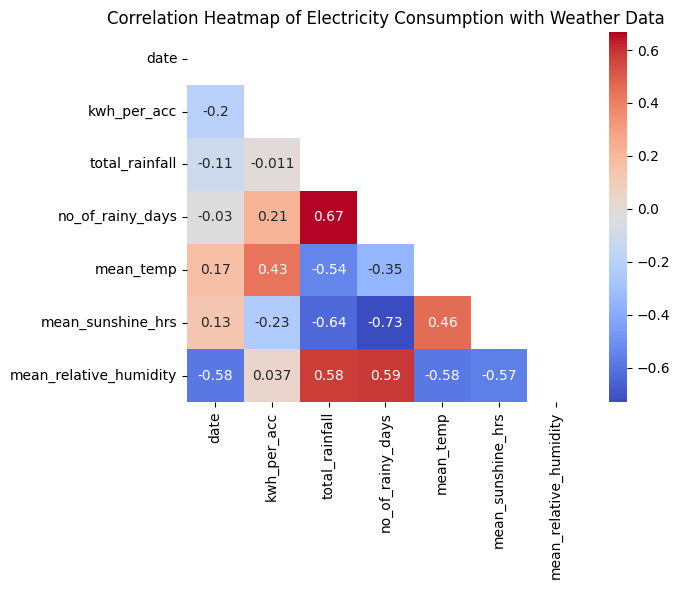

In [53]:
# plotting a heatmap with contrasting color scheme
mask = np.triu(np.ones_like(elec.corr()))
sns.heatmap(elec.corr(), annot=True, cmap='coolwarm', mask = mask)
plt.title('Correlation Heatmap of Electricity Consumption with Weather Data')
plt.show()

*Interpretation: From the heatmap above, we can see a mild correlation between the household consumption of electricity (kwh_per_acc) with the mean temperature of the month, with a correlation coefficient of 0.43. We also see a milder correlation with the mean sunshine hours and the number of rainy days.*

As both the mean temperature of the month and the household expenditure of electricity are quantitative data, the best way to plot and explore its relationship is to use a scatterplot. We will explore that in part 4 below.

##### 2. Visualize distributions using histograms.

In order to understand the distribution shape of the columns, I will visualise distributions of three columns: total rainfall, mean temperature, and household electrical consumption.

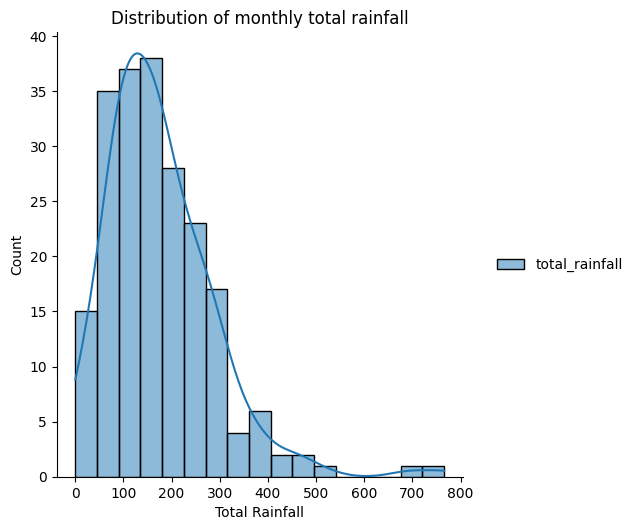

In [54]:
sns.displot([elec['total_rainfall']], kde = True)
plt.title('Distribution of monthly total rainfall')
plt.xlabel("Total Rainfall")
plt.ylabel("Count");

*Interpretation: The distribution of total monthly rainfall is close to a normal distribution, but has a right skew and two outliers. The outliers may lead to skewed estimates as it pulls up the mean and standard deviation.*

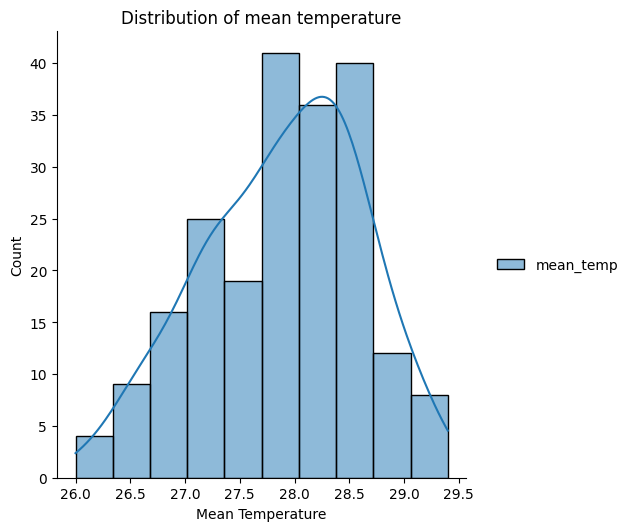

In [55]:
sns.displot([elec['mean_temp']], kde = True)
plt.title('Distribution of mean temperature')
plt.xlabel("Mean Temperature")
plt.ylabel("Count");

The distribution of mean temperature is close to a normal distribution, but has a left skew.*

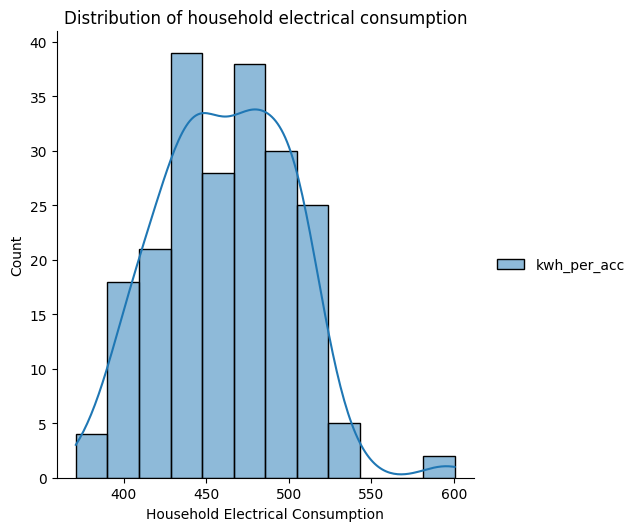

In [56]:
sns.displot([elec['kwh_per_acc']], kde = True)
plt.title('Distribution of household electrical consumption')
plt.xlabel("Household Electrical Consumption")
plt.ylabel("Count");

Similar to the rainfall, the distribution of total monthly rainfall is close to a normal distribution, but has two outliers. The outliers may lead to skewed estimates as it pulls up the mean and standard deviation.*

##### 3. Plot and interpret boxplots.

As we have found that both total rainfall and household electrical consumption have outliers, we will create boxplots for both of them to identify the outliers.

In [57]:
boxplt = px.box(elec, x = 'kwh_per_acc', hover_data=["date"], title = 'Boxplot of household electrical consumption')
boxplt.show()

*Interpretation: By hovering over the boxplot, we can see the value of the lower and upper fences, as well as the quartiles. By hovering over the outliers, we can see that the two outliers are in the months of June and July 2020. This corresponds to the two outliers identified earlier.*

In [58]:
boxplt_rain = px.box(elec, x = 'total_rainfall', hover_data=["date"], title = 'Boxplot of total rainfall')
boxplt_rain.show()

*Interpretation: By hovering over the boxplot, we can see the value of the lower and upper fences, as well as the quartiles. By hovering over the outliers, we can see six outliers. The top three are in the months of December 2006, January 2021, and January 2011. This corresponds to the three outliers identified earlier.*

*However, this boxplot includes three more outliers. This is due to the different calculation of the upper bounds. While I used the standard deviation method earlier, it appears that Plotly used the interquartile range method.*

##### 4. Plot and interpret scatter plots to view relationships between features.

The main scatter plot that I will create is one between the mean temperature and the household consumption of electricity. This is so that we can see the relationship between the two, which has the highest correlation coefficient above, and is the reason for this study.

In [60]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = elec[['mean_temp', 'kwh_per_acc']].dropna().copy()

fig = px.scatter(
    df,
    x='mean_temp',
    y='kwh_per_acc',
    width=900,
    height=800,
    title='Relationship between Mean Temperature and Household Electricity Consumption'
)

# simple linear fit
m, b = np.polyfit(df['mean_temp'], df['kwh_per_acc'], 1)
x_line = np.linspace(df['mean_temp'].min(), df['mean_temp'].max(), 100)
y_line = m * x_line + b

fig.add_trace(
    go.Scatter(
        x=x_line,
        y=y_line,
        mode='lines',
        name='Linear fit'
    )
)

fig.show()

*Interpretation: We see a mild positive relationship between the mean temperature and the household consumption of electricity. The line of best fit has an R^2 value of 0.19, and a coefficient of 23.38.*

*This means that an increase in 1 degree in temperature will result an increase in the household consumption of electricity of 23.38 kWh per household on average.*

Now, let us compare with the scatterplot between the household consumption of electricity, with the total rainfall. This allows us to see the difference between scatterplots with mild correlation and scatterplots with little correlation.

In [61]:
df = elec[['total_rainfall', 'kwh_per_acc']].dropna().copy()

fig = px.scatter(
    df,
    x='total_rainfall',
    y='kwh_per_acc',
    width=900,
    height=800,
    title='Relationship between Total Rainfall and Household Electricity Consumption'
)

# simple linear fit
m, b = np.polyfit(df['total_rainfall'], df['kwh_per_acc'], 1)
x_line = np.linspace(df['total_rainfall'].min(), df['total_rainfall'].max(), 100)
y_line = m * x_line + b

fig.add_trace(
    go.Scatter(
        x=x_line,
        y=y_line,
        mode='lines',
        name='Linear fit'
    )
)

fig.show()

*Interpretation: We see a weak relationship between total rainfall and the household consumption of electricity. The line of best fit has an R^2 value of 0.0001.*

*This shows that there is very little correlation between total rainfall and the household consumption of electricity.*

I wanted to see if there is a visual way to represent the relationship between the mean temperature and the level of household electricity consumption for each month. To do that, we create a line plot, and combined and synchronised the axes. While they are hard to read in terms of numbers, it gives a good visual representation of the relationship between the two.

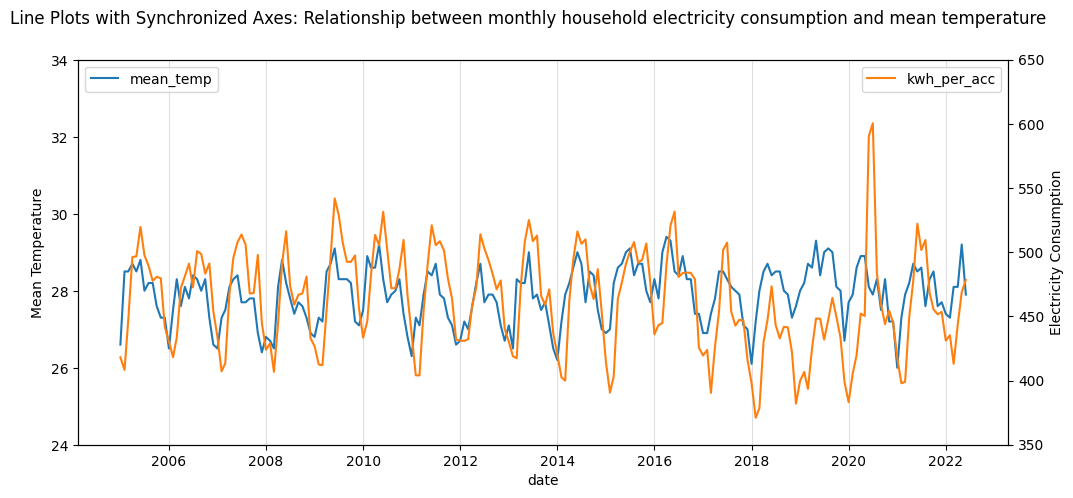

In [62]:
fig = plt.figure(figsize = (12, 5))
fig.suptitle('Line Plots with Synchronized Axes: Relationship between monthly household electricity consumption and mean temperature')

# Plotting the first line
ax1 = sns.lineplot(x = "date", y = "mean_temp",
                    data = elec)
ax1.grid(which = 'both', axis = 'x', visible=True, alpha = 0.4)

# Setting y-axis label
ax1.set_ylabel('Mean Temperature')
ax1.set_ylim(24, 34)

# Setting secondary y-axis label
ax2 = ax1.twinx()
ax2.set_ylabel('Electricity Consumption')
ax2.set_ylim(350,650)

# Plotting the second line
sns.lineplot(x = "date", y = "kwh_per_acc",
             color='tab:orange',
             data=elec, ax = ax2)

# Setting legends
ax1.legend(['mean_temp'], loc = "upper left")
ax2.legend(['kwh_per_acc'], loc = "upper right")

plt.show();

*Interpretation: I plotted the chart of mean temperature and electrical consumption over time, and combined and synchronised the axes. This shows visually that there is likely to be a correlation between the two on a month-to-month level.*

## Conclusions and Recommendations

Based on our data exploration exercise, we have found the following:
1. There is a mild positive correlation between the mean monthly temperature in Singapore, as well as the household consumption of electricity. Based on the linear best fit line, an increase in 1 degree in temperature will result an increase in the household consumption of electricity of 23.38 kWh per household on average.
2. The distribution of electrical consumption is close to normally distributed, while the distributions of total monthly rainfall and mean temperature, are right skewed and left skewed respectively.
3. There are anomalies in the distribution of electrical consumption, and total monthly rainfall.

Due to the mild positive correlation between household electricity consumption and mean temperature, we can expect that there will be an increase in the consumption of electricity as temperature rises. With the current fluctuations of weather in the short term, coupled by the continued global warming long term, it is paramount for the government to ensure that these are taken into account when doing capacity planning in both the short and long run.

However, do note that correlation does not imply causation, and more studies need to be done in order to identify other factors that affect the level of electricity consumption. Additionally, there might be other factors that are correlated with both temperature and the level of electricity consumption that is the true causal factor of the latter.

Based on the results, I would recommend the following next steps:
1. Clean the data of outliers, and plot the graphs again to see if there's a stronger correlation between the mean temperature and the household electricity consumption, as well as an improved R^2 value.
2. Understand the relationship between temperature and electricity consumption on a more granular level, by breaking down into different subzones as well as different types of electricity consumption (manufacturing, construction, etc.).
3. Consider and find other factors that could affect electricity consumption in Singapore, in order to support more accurate capacity planning in the future.
4. Build machine learning models to predict possible future temperature fluctuations and trends, and include these predictions in the planning of future electricity requirements for Singapore. However, this should not be the only determinant in the planning of future electricity requirements; we should incorporate other factors that we find from point 3 above.

In [63]:
elec

,date,kwh_per_acc,total_rainfall,no_of_rainy_days,mean_temp,mean_sunshine_hrs,mean_relative_humidity
54,2005-01-01,418.1,163.2,8,26.6,6.5,83.3
58,2005-02-01,408.3,8.4,3,28.5,9.1,77.7
59,2005-03-01,446.9,82.4,12,28.5,7.2,80.3
60,2005-04-01,496.2,81.7,10,28.7,7.0,81.0
61,2005-05-01,496.8,331.1,20,28.5,5.5,84.6
...,...,...,...,...,...,...,...
49,2022-02-01,435.3,175.0,16,27.3,5.9,80.3
50,2022-03-01,413.1,163.2,21,28.1,6.4,79.2
51,2022-04-01,443.6,239.6,18,28.1,5.2,80.0
52,2022-05-01,468.9,102.0,12,29.2,6.7,76.5


In [64]:
elec.to_csv('data/elec.csv', index = False)